h = 0.01
Average y value = 1.9101617792186754
x closest to 15 = 15.002830246369596
y(x ~ 15) = 0.2324896386610591
Average error = 0.3690162712706905
Local error at x ~ 15 = 0.04106052254898224

h = 0.060000000000000005
Average y value = 0.884905389567876
x closest to 15 = 15.017173296318322
y(x ~ 15) = 0.1042254523988114
Average error = 1.3922379560843439
Local error at x ~ 15 = 0.1754032854140238

h = 0.11
Average y value = 0.48065123161642326
x closest to 15 = 14.991459680288136
y(x ~ 15) = 0.04286503543849603
Average error = 1.794459996235951
Local error at x ~ 15 = 0.2260112130313603

h = 0.16000000000000003
Average y value = 0.29112883962400604
x closest to 15 = 15.066821910073498
y(x ~ 15) = 0.019054816287470553
Average error = 1.9819611058474118
Local error at x ~ 15 = 0.2832797434794434

h = 0.21000000000000002
Average y value = 0.1880470798080326
x closest to 15 = 14.970005262072167
y(x ~ 15) = 0.006317489411607971
Average error = 2.0830076538457947
Local error at x ~ 15 = 0.2

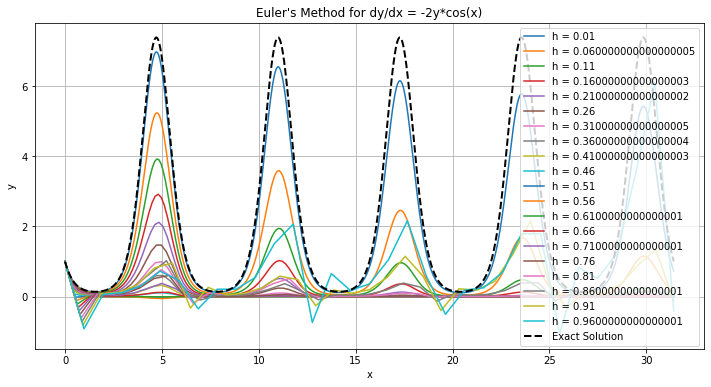

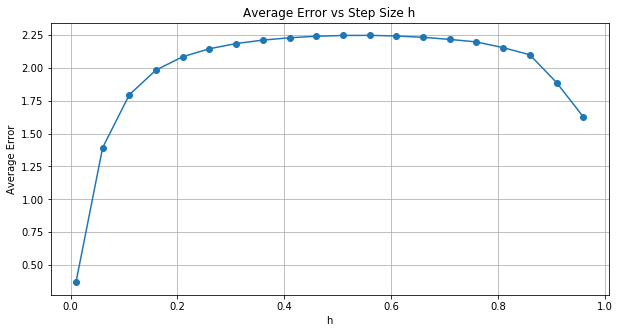

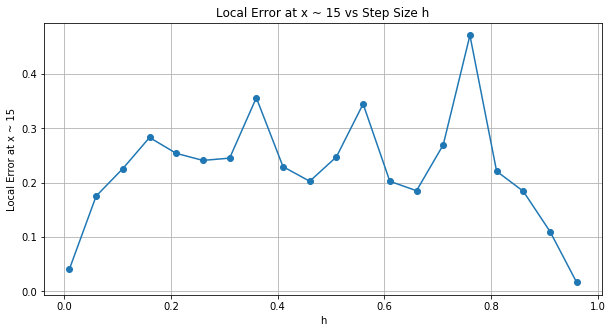

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y * np.cos(x)

def y_exact(x):
    return np.exp(-2 * np.sin(x))

def euler_method(h, x_start, x_end, y0):
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    y_values[0] = y0

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    return x_values, y_values

x_start = 0
x_end = 10 * np.pi
y0 = 1
h_values = np.arange(0.01, 1.01, 0.05)
avg_error_values = []
local_error_values = []
y15values = []

plt.figure(figsize=(12, 6))

for h in h_values:
    x_values, y_values = euler_method(h, x_start, x_end, y0)
    plt.plot(x_values, y_values, label=f"h = {h}")

    y_true = y_exact(x_values)

    avg_error = np.mean(np.abs(y_values - y_true))
    avg_error_values.append(avg_error)

    idx_15 = np.argmin(np.abs(x_values - 15))
    y15 = y_values[idx_15]
    y15values.append(y15)

    local_error = abs(y_values[idx_15] - y_exact(x_values[idx_15]))
    local_error_values.append(local_error)

    print(f"h = {h}")
    print(f"Average y value = {np.mean(y_values)}")
    print(f"x closest to 15 = {x_values[idx_15]}")
    print(f"y(x ~ 15) = {y15}")
    print(f"Average error = {avg_error}")
    print(f"Local error at x ~ 15 = {local_error}")
    print()

x_exact = np.linspace(x_start, x_end, 2000)
plt.plot(x_exact, y_exact(x_exact), 'k--', linewidth=2, label='Exact Solution')

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler's Method for dy/dx = -2y*cos(x)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(h_values, avg_error_values, 'o-')
plt.xlabel('h')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size h')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(h_values, local_error_values, 'o-')
plt.xlabel('h')
plt.ylabel('Local Error at x ~ 15')
plt.title('Local Error at x ~ 15 vs Step Size h')
plt.grid(True)
plt.show()

As the step size h decreases, the Euler's method gets closer to the actual solution. However, as it increases, the method presents a poorer approximation of the solution; the local error also greatly increases where the exact solution "peaks". It is important to not that the local error seems to fluxuate as opposed to the gradual increase in the average error. This is due to the fact that, as previously mentioned, the error peaks when the solution reaches its greatest curvature, and the local error decreases as both the method and the exact solution trail close to zero. Euler's method utilizes linear approximation, so it is less effective where the graph curves the most.

[HW 7s]
a = lambda

From the differential equation, a(x) can be established as
a(x) = -2cos(x)

Now, we can take the Euler stability condition and substitute lambda.

|1+ha|<1
|1-2cos(x)h|<1

-1<cos(x)<1, so we'll do a worst-case analysis at cos(x)=1

|1-2h|<1

0<h<1

For stability in Euler's method for the equation, the step size must be between 0 and 1.